# Protein and mRNA Overlay

This script is meant to combine the mRNA and protein data using two method
1. First to find the median midpoint and to scale all data based off the location of this midpoint
2. Second is to couch the data. Finding the find vales for x and y and scaling the data.

I also need to fix the problems with the protein data no lining up perfectly. 

## mRNA Data Load

In [27]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

TMA_Core="C" # Should be A,B,C 

# #Load files on laptop
# expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

#Load files on desktop
# expr= pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
# #expr=expr_orig.transpose()
# metadata = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
# umap = pd.read_csv(fr"C:\Users\ejohns\Documents\Shapiro Data Files\CutdownRNAFiles\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

#Load files on laptop
expr= pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNAexpression_TMA{TMA_Core}_transposed.csv", index_col=0)
#expr=expr_orig.transpose()
metadata = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_meta_transposed.csv", index_col=0)
umap = pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\RNA_TMA{TMA_Core}_umap_transposed.csv", index_col=0)

# Extra - MetaData File
extra_metadata=pd.read_csv(fr"C:\Users\evanj\OneDrive\Documents\Shapiro Data Files\Laptop Cutdown RNA Files\Run_TMA{TMA_Core}_metadata_file.csv", index_col=0)

# Create AnnData object
adata_rna = sc.AnnData(X=expr.values)

# Assign metadata
adata_rna.obs = metadata
adata_rna.var_names = expr.columns
adata_rna.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
adata_rna.obsm["spatial"] = metadata[['x_pixel', 'y_pixel']].values  # adjust if needed
# x_pixel, y_pixel, x_norm	y_norm	x_micron	y_micron x_cent	y_cent

adata_rna.obsm["X_umap"] = umap.values

## mRNA Functions

In [4]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re

def find_area_mRNA(adata,sample_id):
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]
    
    x_max=0.0
    y_max=0.0
    x_min=100000000
    y_min=100000000
    area=0.0
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        results
        x=abs(row["x_pixel"])
        y=abs(row["y_pixel"])
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    # print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    # print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")

     #Covert to microns
    x_max=x_max*0.168
    y_max=y_max*0.168
    x_min=x_min*0.168
    y_min=y_min*0.168

    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")

    # Area in microns squared 
    area=(x_max-x_min)*(y_max-y_min)
    
    return area
# Function to get the global coordinates
def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    return {
        "Global X": global_x,
        "Global Y": global_y
    }


def find_matching_global_coords(extra_metadata, cell_num, FOV_num):
    import numpy as np
    import pandas as pd
    
    # Ensure the index is reset so FOV becomes a column (if needed)
    filtered_row = extra_metadata.reset_index()
    filtered_row = filtered_row[(filtered_row['fov'] == FOV_num) & (filtered_row['cell_ID'] == cell_num)]

    if filtered_row.empty:
        print(f"No match found for FOV={FOV_num} and cell_ID={cell_num}.")
        return None

    global_x = filtered_row['CenterX_global_px'].values[0] * 0.168 * 0.001
    global_y = filtered_row['CenterY_global_px'].values[0] * 0.168 * 0.001

    return {
        "Global X": global_x,
        "Global Y": global_y
    }

def find_area_mRNA_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    rna_subset = adata[adata.obs.tma_fov_id == sample_id]

    print(sample_id)
    
    # Initialize min and max values to properly handle negative coordinates
    x_max = -10000000000000000000000000000000000000000
    y_max = -10000000000000000000000000000000000000000
    x_min = 10000000000000000000000000000000000000000
    y_min = 10000000000000000000000000000000000000000
    number_of_cells=0
    
     #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in rna_subset.obs.iterrows():
        
        # Updated regular expression: \d+ for Run, [A-Za-z] for the TMA letter
        match = re.search(r'_Run\d+\.TMA[A-Za-z]_(\d+)_(\d+)', cell_id)
        cell_num = int(match.group(1))
        FOV_num = int(match.group(2))

        # Get the global coordinates
        results=find_matching_global_coords(extra_metadata,cell_num,FOV_num)
        x=results["Global X"]
        y=results["Global Y"]
        
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }


def plot_spatial_rectangles_mRNA2(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=1.5,
            edgecolor='royalblue',
            facecolor='skyblue',
            alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    #ax.invert_xaxis()
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()


def plot_spatial_rectangles_mRNA(dataframe, figsize=(12, 8), xlim=None, ylim=None):
    """
    Plots the rectangular areas defined in the dataframe with consistent sizing.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        figsize (tuple): Optional. Tuple specifying the figure size in inches (width, height).
        xlim (tuple): Optional. Tuple specifying the x-axis limits (min, max).
        ylim (tuple): Optional. Tuple specifying the y-axis limits (min, max).
    """
    fig, ax = plt.subplots(figsize=figsize)

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set fixed limits if provided to ensure consistent plot size
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    
    # This combination now produces a consistent plot area
    ax.set_aspect('equal', adjustable='box')
    #ax.invert_yaxis()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Main Execution

TMA_C_FOV1
Sample ID:TMA_C_FOV1 Xmax = 58.17028799999996, Xmin = 57.42167999999996
Sample ID:TMA_C_FOV1 Ymax = 9.041128, Ymin = 8.292352000000001
TMA_C_FOV2
Sample ID:TMA_C_FOV2 Xmax = 55.68194400000003, Xmin = 54.93451200000003
Sample ID:TMA_C_FOV2 Ymax = 9.406127999999994, Ymin = 8.657687999999993
TMA_C_FOV3
Sample ID:TMA_C_FOV3 Xmax = 58.14128799999996, Xmin = 57.392847999999965
Sample ID:TMA_C_FOV3 Ymax = 5.807288000000005, Ymin = 5.059016000000004
TMA_C_FOV4
Sample ID:TMA_C_FOV4 Xmax = 55.97276799999999, Xmin = 55.22667999999999
Sample ID:TMA_C_FOV4 Ymax = 6.548624000000007, Ymin = 5.799680000000007
TMA_C_FOV5
Sample ID:TMA_C_FOV5 Xmax = 50.005600000000015, Xmin = 49.260016000000014
Sample ID:TMA_C_FOV5 Ymax = 6.676448, Ymin = 5.9296880000000005
TMA_C_FOV6
Sample ID:TMA_C_FOV6 Xmax = 47.85794399999996, Xmin = 47.11067999999996
Sample ID:TMA_C_FOV6 Ymax = 3.447287999999995, Ymin = 2.6993519999999953
TMA_C_FOV7
Sample ID:TMA_C_FOV7 Xmax = 53.010936000000044, Xmin = 52.26518400000005

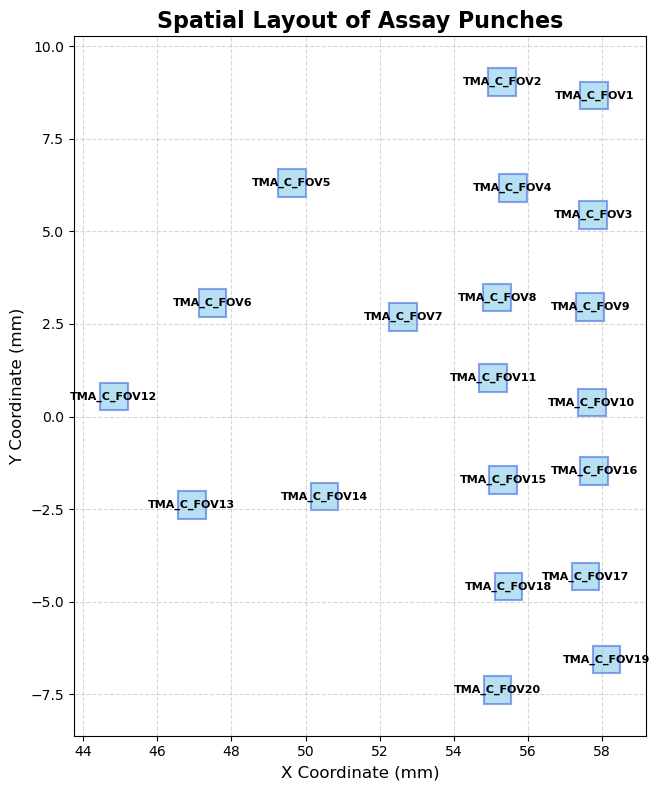

In [28]:

# 2. Process the data to get rectangle coordinates
data=[]
TMA_CORE=["A","B","C"]
for i in range(1,21):
    for j in range(3,4):  # This loop only runs once with j=1
        rna_sample_id = f"TMA_{TMA_CORE[j-1]}_FOV{i}"
        print
        results = find_area_mRNA_global_coords(adata_rna, rna_sample_id)
        dataset="mRNA"

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": rna_sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length,
            "Dataset": dataset
        })

global_rectangles_mRNA = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles_mRNA)


# 4. Generate and show the plot
plot_spatial_rectangles_mRNA2(global_rectangles_mRNA)


## mRNA Output Translation & Display

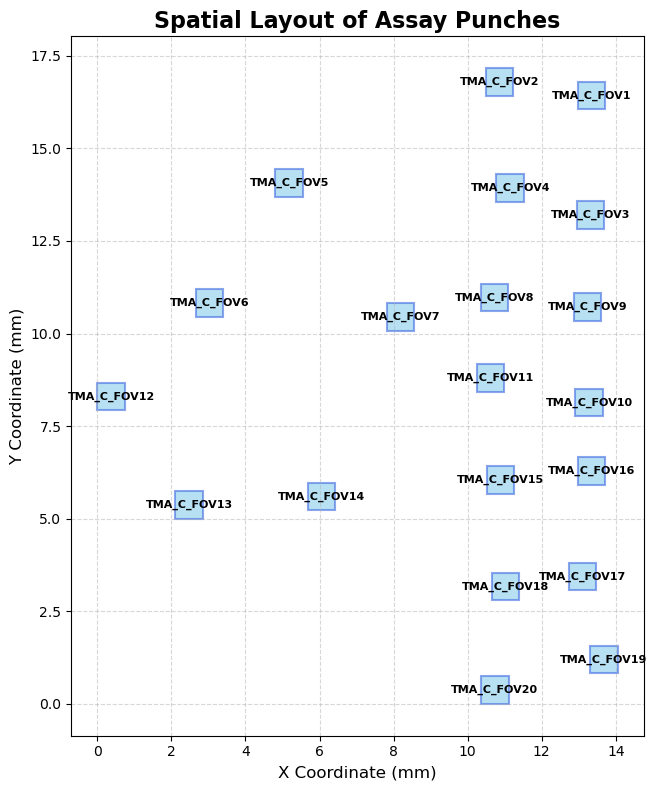

In [29]:
# Find the global minima
global_min_x = global_rectangles_mRNA["X Min (mm)"].min()
global_min_y = global_rectangles_mRNA["Y Min (mm)"].min()

# Create translated DataFrame (same format as original)
translated_global_rectangles = global_rectangles_mRNA.copy()

# Translate coordinates
translated_global_rectangles["X Min (mm)"] = (
    translated_global_rectangles["X Min (mm)"] - global_min_x
)
translated_global_rectangles["X Max (mm)"] = (
    translated_global_rectangles["X Max (mm)"] - global_min_x
)
translated_global_rectangles["Y Min (mm)"] = (
    translated_global_rectangles["Y Min (mm)"] - global_min_y
)
translated_global_rectangles["Y Max (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - global_min_y
)

# Lengths remain the same after translation
# but we can recompute to avoid rounding drift
translated_global_rectangles["X Length(mm)"] = (
    translated_global_rectangles["X Max (mm)"] - translated_global_rectangles["X Min (mm)"]
)
translated_global_rectangles["Y Length (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - translated_global_rectangles["Y Min (mm)"]
)
plot_spatial_rectangles_mRNA2(translated_global_rectangles)

translated_global_rectangles_mRNA=translated_global_rectangles

In [11]:
# Find the global minima
global_min_x = global_rectangles["X Min (mm)"].min()
global_min_y = global_rectangles["Y Min (mm)"].min()

# Create translated DataFrame (same format as original)
translated_global_rectangles = global_rectangles.copy()

# Translate coordinates
translated_global_rectangles["X Min (mm)"] = (
    translated_global_rectangles["X Min (mm)"] - global_min_x
)
translated_global_rectangles["X Max (mm)"] = (
    translated_global_rectangles["X Max (mm)"] - global_min_x
)
translated_global_rectangles["Y Min (mm)"] = (
    translated_global_rectangles["Y Min (mm)"] - global_min_y
)
translated_global_rectangles["Y Max (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - global_min_y
)

# Lengths remain the same after translation
# but we can recompute to avoid rounding drift
translated_global_rectangles["X Length(mm)"] = (
    translated_global_rectangles["X Max (mm)"] - translated_global_rectangles["X Min (mm)"]
)
translated_global_rectangles["Y Length (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - translated_global_rectangles["Y Min (mm)"]
)

print(translated_global_rectangles.head())


plot_spatial_rectangles_mRNA2(translated_global_rectangles)

NameError: name 'global_rectangles' is not defined

## Protein Data Files

In [12]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np

# Load files on Evan's Laptop
expr_orig = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\expression.csv", index_col=0)
expr=expr_orig.transpose()
metadata = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\metadata.csv", index_col=0)
umap = pd.read_csv(r"C:\Users\evanj\OneDrive\Documents\umap.csv", index_col=0)

#Load files on Lab computer
# expr_orig = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\expression.csv", index_col=0)
# expr=expr_orig.transpose()
# metadata = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\metadata.csv", index_col=0)
# umap = pd.read_csv(r"C:\Users\ejohns\Documents\Shapiro Data Files\umap.csv", index_col=0)

# Create AnnData object
adata = sc.AnnData(X=expr.values)

# Assign metadata
adata.obs = metadata
adata.var_names = expr.columns
adata.obs_names = expr.index

# Add spatial coordinates and UMAP to .obsm
# adata.obsm["spatial"] = metadata[['x_FOV_px', 'y_FOV_px']].values  # adjust if needed
adata.obsm["spatial"] = metadata[['x_FOV_px']].assign(y_FOV_px = -metadata['y_FOV_px']).values # Note that the Y acis is inverted. This is done to standardize with RNA plots

## Protein Functions

In [13]:
import pandas as pd
import numpy as np
import anndata
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def find_area_protein_global_coords(adata,sample_id):

    # Filter the AnnData object to only the cells from this sample
    protein_subset = adata[adata.obs.index.str.startswith(sample_id)]
    
    x_max=-100000000000000000000000
    y_max=-100000000000000000000000
    x_min=10000000000000000000000
    y_min=10000000000000000000000
    number_of_cells=0
    
    #Loop to find the x and y coords. Def not the smartest way to do this but it is simiple
    for cell_id, row in protein_subset.obs.iterrows():
        x=row["x_slide_mm"]
        y=row["y_slide_mm"]
        if x>x_max:
            x_max=x
        if y>y_max:
            y_max=y
        if x<x_min:
            x_min=x
        if y<y_min:
            y_min=y
        number_of_cells+=1
    
    # Display
    print(f"Sample ID:{sample_id} Xmax = {x_max}, Xmin = {x_min}")
    print(f"Sample ID:{sample_id} Ymax = {y_max}, Ymin = {y_min}")
    
    return{
        "X Max":x_max,
        "X Min":x_min,
        "Y Max":y_max,
        "Y Min":y_min
    }
def find_area_protein_global_coords_optimized(adata, sample_id):
    """
    An optimized function to find the min/max spatial coordinates for a given sample.
    This version uses pandas' built-in, vectorized functions (.min(), .max()) 
    which are significantly faster than iterating through rows.
    
    Args:
        adata (anndata.AnnData): The AnnData object containing cell data.
        sample_id (str): The identifier for the sample to analyze.
        
    Returns:
        dict: A dictionary with the min/max x and y coordinates.
    """
    # Filter the AnnData object to only the cells from this sample
    protein_subset_obs = adata.obs[adata.obs.index.str.startswith(sample_id)]
    
    if protein_subset_obs.empty:
        print(f"Warning: No cells found for sample ID: {sample_id}")
        return {
            "X Max": np.nan, "X Min": np.nan,
            "Y Max": np.nan, "Y Min": np.nan
        }
        
    # Directly calculate min and max on the relevant columns
    x_max = protein_subset_obs["x_slide_mm"].max()
    x_min = protein_subset_obs["x_slide_mm"].min()
    y_max = protein_subset_obs["y_slide_mm"].max()
    y_min = protein_subset_obs["y_slide_mm"].min()
    
    return {
        "X Max": x_max, "X Min": x_min,
        "Y Max": y_max, "Y Min": y_min
    }

def plot_spatial_rectangles(dataframe):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
    """
    fig, ax = plt.subplots(figsize=(12, 8))

    # Iterate through the DataFrame to create and add each rectangle patch
    for index, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        # Create a Rectangle patch
        # We use a semi-transparent fill to see overlaps
        rect = patches.Rectangle(
            (x_min, y_min), 
            x_length, 
            y_length, 
            linewidth=1.5, 
            edgecolor='royalblue', 
            facecolor='skyblue',
            alpha=0.6
        )

        # Add the patch to the Axes
        ax.add_patch(rect)
        
        # Add the sample ID as a label in the center of the rectangle
        ax.text(
            x_min + x_length / 2, 
            y_min + y_length / 2, 
            sample_id, 
            ha='center', 
            va='center', 
            fontsize=8, 
            fontweight='bold'
        )

    # --- Plot Styling ---
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    
    # Set aspect ratio to 'equal' to ensure rectangles are not distorted
    ax.set_aspect('equal', adjustable='box')
    
    # Invert Y-axis as is common for image/slide coordinates (origin at top-left)
    ax.invert_yaxis()
    
    # Automatically adjust plot limits to fit all data
    ax.autoscale_view()
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_spatial_rectangles_protein(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min and X/Y Length.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]

        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=1.5,
            edgecolor='royalblue',
            facecolor='skyblue',
            alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    # ax.invert_yaxis()
    # ax.invert_xaxis()
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()

## Main Execution

In [32]:
# --- Main Execution ---

# 1. Load your data (or use the mock data for testing)
# If you have your data, load it here:


# 2. Process the data to get rectangle coordinates
data = []
for i in range(3, 21):
    for j in range(3,4):
        dataset="Protein"
        sample_id = f"c_{j}_{i}"
        results = find_area_protein_global_coords_optimized(adata, sample_id)

        # Calculate length of dimensions of the samples
        x_length = results["X Max"] - results["X Min"]
        y_length = results["Y Max"] - results["Y Min"]

        data.append({
            "sample_id": sample_id,
            "X Min (mm)": results["X Min"],
            "X Max (mm)": results["X Max"],
            "Y Min (mm)": results["Y Min"],
            "Y Max (mm)": results["Y Max"],
            "X Length(mm)": x_length,
            "Y Length (mm)": y_length,
            "Dataset": dataset
        })

global_rectangles_protein = pd.DataFrame(data).dropna()


# 3. Display the resulting DataFrame
print("Calculated Rectangle Coordinates and Dimensions:")
print(global_rectangles_protein)
# # 4. Generate and show the plot
# plot_spatial_rectangles_protein(global_rectangles)


Calculated Rectangle Coordinates and Dimensions:
   sample_id  X Min (mm)  X Max (mm)  Y Min (mm)  Y Max (mm)  X Length(mm)  \
0      c_3_3   -0.245960    0.503656    3.235344    3.984960      0.749616   
1      c_3_4    1.977536    2.727824    2.889008    3.639296      0.750288   
2      c_3_5    7.930208    8.678480    2.466848    3.215624      0.748272   
3      c_3_6   10.053872   10.803320    5.533512    6.283464      0.749448   
4      c_3_7    4.727536    5.477320    5.977176    6.726960      0.749784   
5      c_3_8    2.163872    2.913824    5.782840    6.533128      0.749952   
6      c_3_9   -0.389464    0.360488    5.802008    6.552296      0.749952   
7     c_3_10   -0.479960    0.269320    8.375848    9.124960      0.749280   
8     c_3_11    1.989040    2.738320    7.892176    8.641960      0.749280   
9     c_3_12   12.361200   13.110648    8.224848    8.973624      0.749448   
10    c_3_13   10.266536   11.016488   11.078840   11.829296      0.749952   
11    c_3_14   

## Translation and plotting layer

,sample_id,X Min (mm),X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm),Dataset
0,c_3_3,12.606992,13.356608,12.912168,13.661784,0.749616,0.749616,Protein
1,c_3_4,10.382824,11.133112,13.257832,14.008120,0.750288,0.750288,Protein
2,c_3_5,4.432168,5.180440,13.681504,14.430280,0.748272,0.748776,Protein
3,c_3_6,2.307328,3.056776,10.613664,11.363616,0.749448,0.749952,Protein
4,c_3_7,7.633328,8.383112,10.170168,10.919952,0.749784,0.749784,Protein
5,c_3_8,10.196824,10.946776,10.364000,11.114288,0.749952,0.750288,Protein
6,c_3_9,12.750160,13.500112,10.344832,11.095120,0.749952,0.750288,Protein
7,c_3_10,12.841328,13.590608,7.772168,8.521280,0.749280,0.749112,Protein
8,c_3_11,10.372328,11.121608,8.255168,9.004952,0.749280,0.749784,Protein
9,c_3_12,0.000000,0.749448,7.923504,8.672280,0.749448,0.748776,Protein


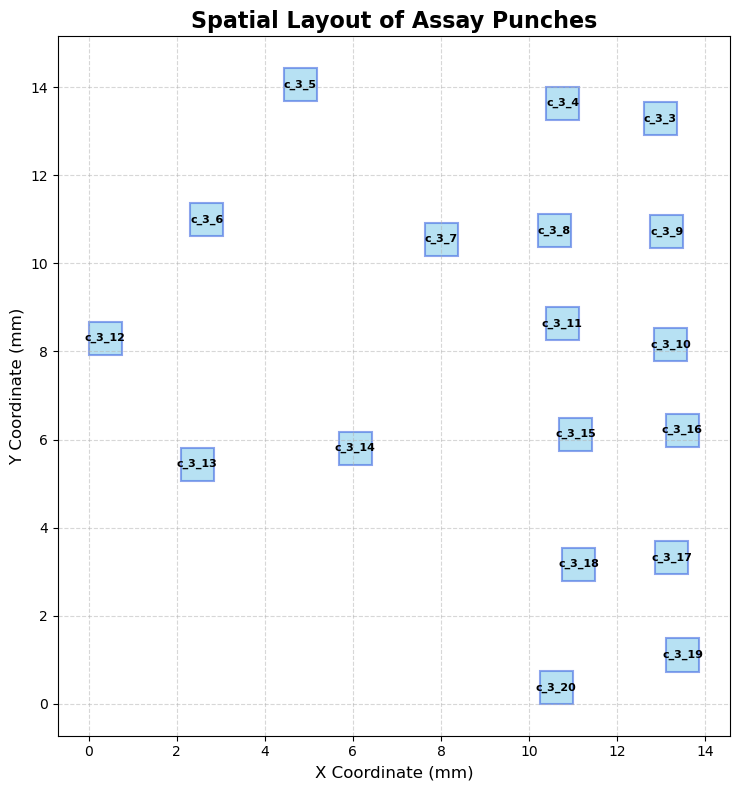

In [33]:
import numpy as np
import pandas as pd

def flip_axes(df, flip_x=True, flip_y=True, ref_max_x=None, ref_max_y=None, validate=True):
    """
    Return a new DataFrame with X and/or Y axes flipped (mirrored).
    - df: DataFrame with columns "X Min (mm)", "X Max (mm)", "Y Min (mm)", "Y Max (mm)", "X Length(mm)", "Y Length (mm)"
    - flip_x/flip_y: whether to flip that axis
    - ref_max_x/ref_max_y: optional numbers to mirror around (useful to match other dataset). 
                           If None, uses df["X Max (mm)"].max() / df["Y Max (mm)"].max()
    - validate: if True, prints a warning if widths/heights changed
    """
    src = df.copy()
    out = src.copy()  # will fill with flipped coordinates

    # Save originals as numpy arrays so we never use overwritten values
    orig_xmin = src["X Min (mm)"].to_numpy()
    orig_xmax = src["X Max (mm)"].to_numpy()
    orig_ymin = src["Y Min (mm)"].to_numpy()
    orig_ymax = src["Y Max (mm)"].to_numpy()

    if flip_x:
        max_x = ref_max_x if ref_max_x is not None else orig_xmax.max()
        new_xmin = max_x - orig_xmax
        new_xmax = max_x - orig_xmin
        out["X Min (mm)"] = new_xmin
        out["X Max (mm)"] = new_xmax

    if flip_y:
        max_y = ref_max_y if ref_max_y is not None else orig_ymax.max()
        new_ymin = max_y - orig_ymax
        new_ymax = max_y - orig_ymin
        out["Y Min (mm)"] = new_ymin
        out["Y Max (mm)"] = new_ymax

    # Ensure min <= max (in case input was inconsistent)
    out["X Min (mm)"], out["X Max (mm)"] = (
        np.minimum(out["X Min (mm)"], out["X Max (mm)"]),
        np.maximum(out["X Min (mm)"], out["X Max (mm)"])
    )
    out["Y Min (mm)"], out["Y Max (mm)"] = (
        np.minimum(out["Y Min (mm)"], out["Y Max (mm)"]),
        np.maximum(out["Y Min (mm)"], out["Y Max (mm)"])
    )

    # Recompute lengths
    out["X Length(mm)"] = out["X Max (mm)"] - out["X Min (mm)"]
    out["Y Length (mm)"] = out["Y Max (mm)"] - out["Y Min (mm)"]

    # Validation (widths/heights should match originals)
    if validate:
        x_ok = np.allclose(src["X Length(mm)"].to_numpy(), out["X Length(mm)"].to_numpy())
        y_ok = np.allclose(src["Y Length (mm)"].to_numpy(), out["Y Length (mm)"].to_numpy())
        if not (x_ok and y_ok):
            print("WARNING: width/height changed after flip.")
            print("Max abs diff X length:", np.max(np.abs(src["X Length(mm)"] - out["X Length(mm)"])))
            print("Max abs diff Y length:", np.max(np.abs(src["Y Length (mm)"] - out["Y Length (mm)"])))

    return out
aligned_protein = flip_axes(global_rectangles_protein, flip_x=True, flip_y=True)

display(aligned_protein)

plot_spatial_rectangles_protein(aligned_protein)

## Combined Plots - Centroid Alignment 

In [ ]:
# Write function that can convert dataset into centoid aligned 



## Combined Plots Couched Alignment

In [34]:
# Combine the columns on the same dataframe 
Combined_DataFrame = pd.concat([aligned_protein, translated_global_rectangles_mRNA], ignore_index=True)

display(Combined_DataFrame)

,sample_id,X Min (mm),X Max (mm),Y Min (mm),Y Max (mm),X Length(mm),Y Length (mm),Dataset
0,c_3_3,12.606992,13.356608,12.912168,13.661784,0.749616,0.749616,Protein
1,c_3_4,10.382824,11.133112,13.257832,14.008120,0.750288,0.750288,Protein
2,c_3_5,4.432168,5.180440,13.681504,14.430280,0.748272,0.748776,Protein
3,c_3_6,2.307328,3.056776,10.613664,11.363616,0.749448,0.749952,Protein
4,c_3_7,7.633328,8.383112,10.170168,10.919952,0.749784,0.749784,Protein
5,c_3_8,10.196824,10.946776,10.364000,11.114288,0.749952,0.750288,Protein
6,c_3_9,12.750160,13.500112,10.344832,11.095120,0.749952,0.750288,Protein
7,c_3_10,12.841328,13.590608,7.772168,8.521280,0.749280,0.749112,Protein
8,c_3_11,10.372328,11.121608,8.255168,9.004952,0.749280,0.749784,Protein
9,c_3_12,0.000000,0.749448,7.923504,8.672280,0.749448,0.748776,Protein


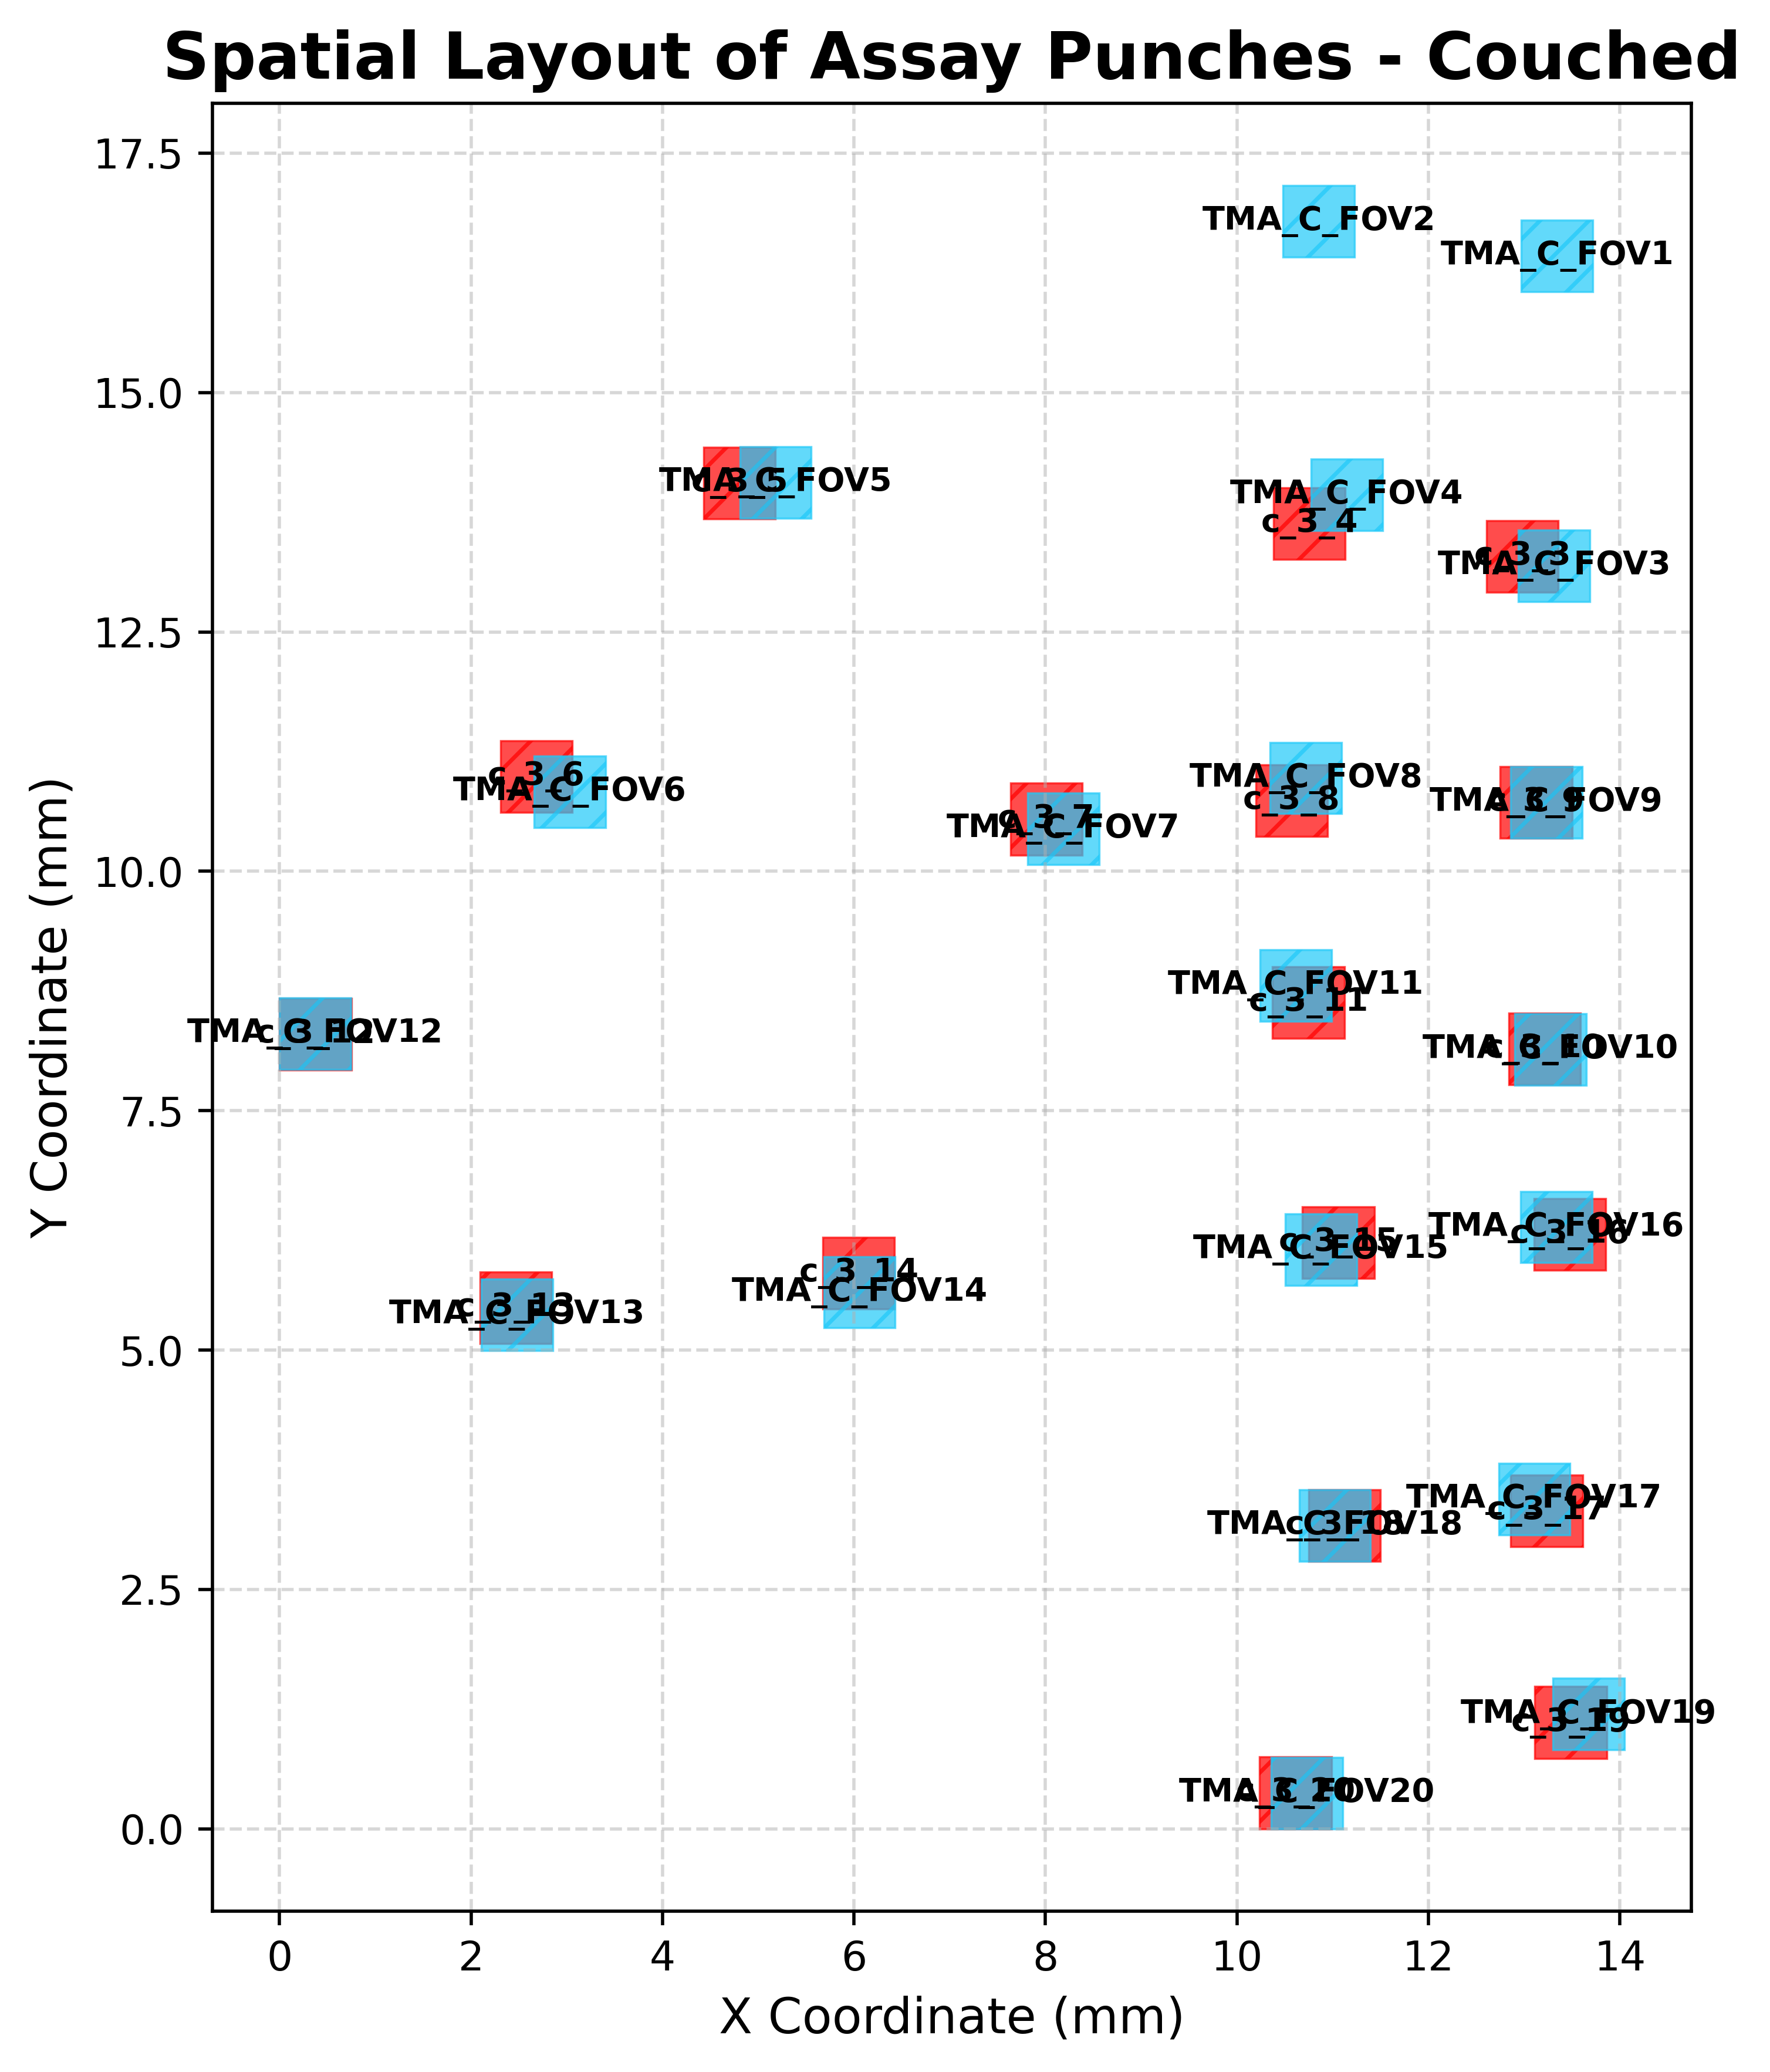

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def plot_spatial_rectangles_combined(dataframe, ax=None):
    """
    Plots the rectangular areas defined in the dataframe, with colors based on dataset type.

    Args:
        dataframe (pd.DataFrame): DataFrame with columns for X/Y Min, X/Y Length, sample_id, and dataset.
        ax (matplotlib.axes.Axes, optional): Matplotlib Axes object to plot on. 
                                             If None, a new figure and axes are created.
    """
    # Create a new figure and axes if not provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 8))
        show_plot = True
    else:
        show_plot = False

    # Define colors for each dataset type
    color_map = {
        "Protein": {
            "edgecolor": "#ff0000",
            "facecolor": "#ff0000",  # bright red
            "alpha": 0.7,
            "linewidth": 0.5,
            "hatch": "//"
        },
        "mRNA": {
            "edgecolor": "#1FC9F9",
            "facecolor": "#1FC9F9",  # soft blue
            "alpha": 0.7,
            "linewidth": 0.5,
            "hatch": "//"
        }
    }

    for _, row in dataframe.iterrows():
        x_min = row["X Min (mm)"]
        y_min = row["Y Min (mm)"]
        x_length = row["X Length(mm)"]
        y_length = row["Y Length (mm)"]
        sample_id = row["sample_id"]
        dataset_type = row["Dataset"]
    
        colors = color_map.get(dataset_type, {
            "edgecolor": "black",
            "facecolor": "gray",
            "alpha": 0.6,
            "linewidth": 1.0,
            "hatch": ""
        })
    
        rect = patches.Rectangle(
            (x_min, y_min),
            x_length,
            y_length,
            linewidth=colors["linewidth"],
            edgecolor=colors["edgecolor"],
            facecolor=colors["facecolor"],
            hatch=colors["hatch"],
            alpha=colors["alpha"]
        )
        ax.add_patch(rect)
        ax.text(
            x_min + x_length / 2,
            y_min + y_length / 2,
            sample_id,
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold'
        )

    # Styling
    ax.set_title('Spatial Layout of Assay Punches - Couched', fontsize=16, fontweight='bold')
    ax.set_xlabel('X Coordinate (mm)', fontsize=12)
    ax.set_ylabel('Y Coordinate (mm)', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.autoscale_view()
    ax.grid(True, linestyle='--', alpha=0.5)

    if show_plot:
        plt.tight_layout()
        plt.show()

fig, ax = plt.subplots(figsize=(12, 8), dpi=500)
plot_spatial_rectangles_combined(Combined_DataFrame, ax=ax)



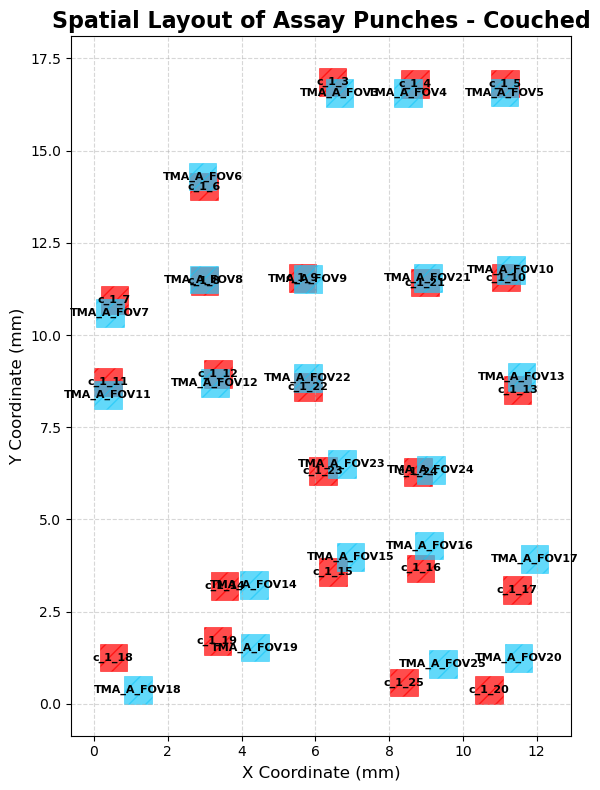

In [25]:
plot_spatial_rectangles_combined(Combined_DataFrame)

## Old Code

  sample_id  X Min (mm)  X Max (mm)  Y Min (mm)  Y Max (mm)  X Length(mm)  \
0     c_1_3    5.014496    5.764112    0.000000    0.750120      0.749616   
1     c_1_4    2.787664    3.536776    0.064168    0.813448      0.749112   
2     c_1_5    0.344328    1.093776    0.041336    0.791288      0.749448   
3     c_1_6    8.503168    9.251944    2.837168    3.587288      0.748776   
4     c_1_7   10.925504   11.673776    5.908352    6.655616      0.748272   

   Y Length (mm)  Dataset  
0       0.750120  Protein  
1       0.749280  Protein  
2       0.749952  Protein  
3       0.750120  Protein  
4       0.747264  Protein  


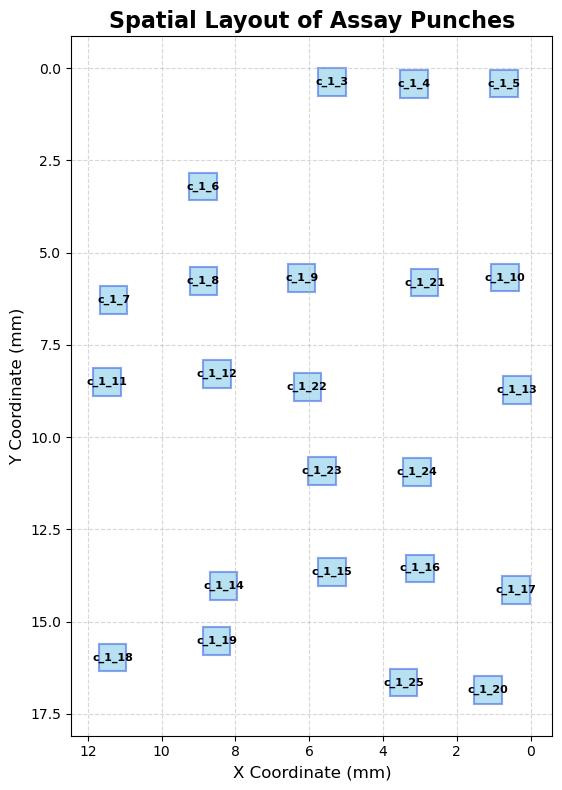

In [35]:
# Find the global minima
global_min_x = global_rectangles["X Min (mm)"].min()
global_min_y = global_rectangles["Y Min (mm)"].min()

# Create translated DataFrame (same format as original)
translated_global_rectangles = global_rectangles.copy()

# Translate coordinates
translated_global_rectangles["X Min (mm)"] = (
    translated_global_rectangles["X Min (mm)"] - global_min_x
)
translated_global_rectangles["X Max (mm)"] = (
    translated_global_rectangles["X Max (mm)"] - global_min_x
)
translated_global_rectangles["Y Min (mm)"] = (
    translated_global_rectangles["Y Min (mm)"] - global_min_y
)
translated_global_rectangles["Y Max (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - global_min_y
)

# Lengths remain the same after translation
# but we can recompute to avoid rounding drift
translated_global_rectangles["X Length(mm)"] = (
    translated_global_rectangles["X Max (mm)"] - translated_global_rectangles["X Min (mm)"]
)
translated_global_rectangles["Y Length (mm)"] = (
    translated_global_rectangles["Y Max (mm)"] - translated_global_rectangles["Y Min (mm)"]
)

print(translated_global_rectangles.head())


plot_spatial_rectangles_protein(translated_global_rectangles)